In [1]:
#GAP_UP_SHORT_STRATEGY ANALYSIS_BACKTEST

#1. IMPORT

import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress
from ib_insync import IB, Stock, util


#2. STRATEGY_PARAMETERS

STOP_LOSS_PCT   = 0.25   # SL
TAKE_PROFIT_PCT = 0.50   # TP
POSITION_SIZE   = 5000   # POS SIZE
FEES            = 50
ENTRY           = "next_open_3" #"next_open" for entry at open after gap_day // "close" for entry at close on gap_day // "next_open_2" for entry at open on day 2 after gap  // "next_open_3" for entry at open on day 3 after gap 
HOLDING_PERIOD  = 5
GAP_THRESHOLD   = 1.10


#3. LOAD_FINVIZ_SCREENER_CSVs

DATA_PATH = Path("/Users/holytrader/Desktop/FinViz_Screener")

PCT_COLS  = ["Performance (Week)", "Performance (Month)",
             "Performance (Quarter)", "Change from Open",
             "Gap", "Change", "Float %"]

#add_filter_here
FILTER    = {"Market Cap": (">",1000),
             "Float %": (">", 0.7)
    
}

def load_screener_data(data_path, filters=None):
    
    records = []
    
    for f in data_path.glob("GU_*.csv"):
        parts = re.findall(r'\d+', f.name)
        
        if len(parts) < 3:
            continue
            
        df = pd.read_csv(f)
        df["date"] = pd.to_datetime(
            f"{parts[0]}-{parts[1]}-{parts[2]}", dayfirst=True
        )
        records.append(df)
        
    if not records:
        raise FileNotFoundError(f"No GU_*.csv files found in {data_path}")
        
    out = pd.concat(records, ignore_index=True)
    out[PCT_COLS] = out[PCT_COLS].apply(
        lambda col: col.str.strip("%").astype(float) / 100
    )
    out["Open_2_Close"] = (out["Price"] - out["Open"]) / out["Open"]
    out["Open_2_Low"]   = (out["Low"]   - out["Open"]) / out["Open"]
    out["Open_2_High"]  = (out["High"]  - out["Open"]) / out["Open"]
    
    if filters:
       for col, (op, val) in filters.items():
            if op == ">":  out = out[out[col] > val]
            if op == ">=": out = out[out[col] >= val]
            if op == "<":  out = out[out[col] < val]
            if op == "<=": out = out[out[col] <= val]

    return out.sort_values("date").reset_index(drop=True)


#4. IB_DOWNLOAD___GAP_FINDER___________________________________________________________________

class DownloadData:
    
    def __init__(self, symbol: str, duration: str, ib: IB):
        
        self.symbol         = symbol
        self.duration       = duration
        self.ib             = ib
        self._df            = pd.DataFrame()
        
    
    def _fetch(self) -> pd.DataFrame:
        
        contract = Stock(self.symbol, "SMART", "USD")
        
        self.ib.qualifyContracts(contract)
        bars = self.ib.reqHistoricalData(
            contract, endDateTime="", durationStr=self.duration,
            barSizeSetting="1 day", whatToShow="TRADES", useRTH=True,
        )
        if not bars:
            print(f"[IB] No data for {self.symbol} – skipping")
            
            return pd.DataFrame()
            
        df = util.df(bars)
        df["Ticker"] = self.symbol
        
        return df

    
    

#5. Backtester_______________________________________________________________________________________________

def backtest(df: pd.DataFrame,
             stop_loss_pct:   float = STOP_LOSS_PCT,
             take_profit_pct: float = TAKE_PROFIT_PCT,
             position_size:   float = POSITION_SIZE,
             entry:           str   = ENTRY,
             holding_period:  int   = HOLDING_PERIOD,
             gap_threshold:   float = GAP_THRESHOLD           
             ): 

    df = df.copy().sort_values("date").reset_index(drop=True)

    N = holding_period
        
    df["prev_close"] = df["close"].shift(1)
    df["next_close"] = df.groupby("Ticker")["close"].shift(-N)
        
    is_gap = df["open"] > (df["prev_close"] * gap_threshold)
    df["gap_performance"] = np.where(
        is_gap,
        (df["close"] - df["open"]) / df["open"],
        np.nan,
    ) 

    if "next_open" in entry:
        parts = entry.split("_")
        if parts[-1].isdigit():
            k = int(parts[-1])
        else:
            k = 1  
    else:
        k = 0

    df["max_high_fwd"] = df["high"].shift(-(k + N - 1)).rolling(window=N, min_periods=N).max()
    df["min_low_fwd"]  = df["low"].shift(-(k + N - 1)).rolling(window=N, min_periods=N).min()

    df["next_open"]   = df["open"].shift(-1)
    df["next_open_1"] = df["next_open"]
    
    for i in range(2, 4):
        df[f"next_open_{i}"] = df["open"].shift(-i)

    df["entry"]        = 0
    df["exit"]         = 0
    df["entry_price"]  = 0.0
    df["exit_price"]   = 0.0
    df["exit_reason"]  = pd.Series(dtype="object")
    df["trade_id"]     = pd.Series(dtype="object")
    df["exit_day"]     = pd.Series(dtype="object") 
    df["entry_day"]    = pd.Series(dtype="object") 

    in_position       = False
    current_entry_idx = None
    i_d               = None
    last_exit_row     = -1  # ← Row-Index statt Datum

    i = 0
    while i < (len(df) - 2):

        # ── ENTRY ────────────────────────────────────────────
        if not in_position:
            is_gap = df["gap_performance"].notna().iloc[i]

            if is_gap:
                entry_idx = i

                # ── Kein Re-Entry auf oder vor Exit-Row ──
                if entry_idx <= last_exit_row:
                    i += 1
                    continue

                if entry == "next_open":
                    if entry_idx + 1 >= len(df):
                        i += 1
                        continue
                    entry_price      = df["next_open"].iloc[entry_idx]
                    actual_entry_day = df["date"].iloc[entry_idx + 1]

                elif entry.startswith("next_open_"):
                    day_num      = int(entry.split("_")[-1])
                    column_name  = f"next_open_{day_num}"
                    if entry_idx + day_num >= len(df):
                        i += 1
                        continue
                    if column_name not in df.columns:
                        print(f"Warnung: Spalte {column_name} existiert nicht!")
                        i += 1
                        continue
                    entry_price      = df[column_name].iloc[entry_idx]
                    actual_entry_day = df["date"].iloc[entry_idx + day_num]

                else:  # close
                    entry_price      = df["close"].iloc[entry_idx]
                    actual_entry_day = df["date"].iloc[entry_idx]

                df.loc[entry_idx, "entry"]       = 1
                df.loc[entry_idx, "entry_price"] = entry_price
                df.loc[entry_idx, "entry_day"]   = actual_entry_day

                date_stamp = pd.Timestamp(df["date"].iloc[entry_idx]).strftime("%Y%m%d")
                i_d        = entry_idx
                trade_id   = f"{df['Ticker'].iloc[entry_idx]}_{date_stamp}_Entry_{i_d}"
                df.loc[entry_idx, "trade_id"] = trade_id

                current_entry_idx = entry_idx
                in_position       = True
                i                 = entry_idx + 1
                continue

        # ── EXIT ─────────────────────────────────────────────
        if in_position and current_entry_idx is not None:
            idx            = current_entry_idx + k + 1
            exit_found     = False
            entry_price    = df["entry_price"].iloc[current_entry_idx]
            current_ticker = df["Ticker"].iloc[current_entry_idx]

            while idx < len(df) and idx <= (current_entry_idx + k + N):
                if df["Ticker"].iloc[idx] != current_ticker:
                    idx = idx - 1
                    break
            
                current_open = df["open"].iloc[idx]
                current_high = df["high"].iloc[idx]
                current_low  = df["low"].iloc[idx]
            
                sl_price = entry_price * (1 + stop_loss_pct)
                tp_price = entry_price * (1 - take_profit_pct)
            
                # Gap über SL → Exit am Open
                if current_open >= sl_price:
                    df.loc[idx, "exit"]        = 1
                    df.loc[idx, "exit_price"]  = current_open
                    df.loc[idx, "exit_reason"] = "stop_loss_gap"
                    df.loc[idx, "exit_day"]    = df["date"].iloc[idx]
                    exit_found = True
                    break
            
                # Intraday SL
                elif current_high >= sl_price:
                    df.loc[idx, "exit"]        = 1
                    df.loc[idx, "exit_price"]  = sl_price
                    df.loc[idx, "exit_reason"] = "stop_loss"
                    df.loc[idx, "exit_day"]    = df["date"].iloc[idx]
                    exit_found = True
                    break
            
                # Gap unter TP → Exit am Open
                elif current_open <= tp_price:
                    df.loc[idx, "exit"]        = 1
                    df.loc[idx, "exit_price"]  = current_open
                    df.loc[idx, "exit_reason"] = "take_profit_gap"
                    df.loc[idx, "exit_day"]    = df["date"].iloc[idx]
                    exit_found = True
                    break
            
                # Intraday TP
                elif current_low <= tp_price:
                    df.loc[idx, "exit"]        = 1
                    df.loc[idx, "exit_price"]  = tp_price
                    df.loc[idx, "exit_reason"] = "take_profit"
                    df.loc[idx, "exit_day"]    = df["date"].iloc[idx]
                    exit_found = True
                    break
            
                idx += 1

            # TIME_EXIT
            if not exit_found:
                idx = int(min(current_entry_idx + k + N, len(df) - 1))
                df.loc[idx, ["exit", "exit_price", "exit_reason", "exit_day"]] = [
                    1, df["close"].iloc[idx], "time_exit", df["date"].iloc[idx]]

            # TRADE_ID
            date_stamp = pd.Timestamp(df["date"].iloc[idx]).strftime("%Y%m%d")
            df.loc[idx, "trade_id"] = f"{df['Ticker'].iloc[idx]}_{date_stamp}_Exit_{i_d}"

            # RESET
            last_exit_row     = idx  # ← Row-Index merken
            in_position       = False
            current_entry_idx = None
            i                 = idx + 1
            continue

        i += 1

    return df


def test_performance(df: pd.DataFrame,
                     stop_loss_pct: float = STOP_LOSS_PCT,
                     position_size: float = POSITION_SIZE,
                     fees:          float = FEES
                     ):

    all_ticker_trades = []

    for ticker, ticker_df in df.groupby("Ticker"):
        ticker_df = ticker_df.sort_values("date").reset_index(drop=True)
        ticker_trades = []
        
        j = 0
        while j < len(ticker_df):
            if ticker_df["entry"].iloc[j] == 1:
                trade = {
                    "trade_id":    ticker_df["trade_id"].iloc[j],
                    "Ticker":      ticker_df["Ticker"].iloc[j],
                    "entry_day":   ticker_df["entry_day"].iloc[j],
                    "entry_price": ticker_df["entry_price"].iloc[j],
                    "max_risk":    ((ticker_df["max_high_fwd"].iloc[j] / ticker_df["entry_price"].iloc[j]) - 1) * POSITION_SIZE,
                    "max_reward":  ((ticker_df["min_low_fwd"].iloc[j] / ticker_df["entry_price"].iloc[j]) - 1) * POSITION_SIZE * -1
                }

                k = j + 1
                exit_found = False
                while k < len(ticker_df):
                    if ticker_df["exit"].iloc[k] == 1:
                        trade["exit_day"]      = ticker_df["exit_day"].iloc[k]
                        trade["exit_price"]    = ticker_df["exit_price"].iloc[k]
                        trade["exit_reason"]   = ticker_df["exit_reason"].iloc[k]
                        trade["trade_id_exit"] = ticker_df["trade_id"].iloc[k]
                        ticker_trades.append(trade)
                        exit_found = True
                        break
                    k += 1

            j += 1

        all_ticker_trades.extend(ticker_trades)

    trades_df = pd.DataFrame(all_ticker_trades)

    if trades_df.empty:
        return trades_df

    trades_df["pnl_abs"]            = trades_df["exit_price"] - trades_df["entry_price"]
    trades_df["pnl_pct"]            = trades_df["pnl_abs"] / trades_df["entry_price"]
    trades_df["trade_pnl"]          = -trades_df["pnl_pct"] * position_size - fees
    trades_df["cum_pnl"]            = trades_df["trade_pnl"].cumsum()
    trades_df["pnl_r_initial_risk"] = trades_df["trade_pnl"] / (position_size * STOP_LOSS_PCT)

    return trades_df

In [3]:
#LOAD_FILTERED_SCREENING_RESULTS

screener_df = load_screener_data(DATA_PATH, filters=FILTER)

#DOWNLOAD_LOOP_IBRK

util.startLoop()
ib = IB()
ib.connect("127.0.0.1", 7497, clientId=3434944)

results = []


for ticker in screener_df["Ticker"]:
    try:
        df = DownloadData(ticker, "20 W", ib)._fetch()
        if not df.empty:
            results.append(df)
            print(f"✓ {ticker}")
    except Exception as e:
        print(f"✗ {ticker}: {e}")

ib.disconnect()


df_all = (
    pd.concat(results, ignore_index=True)
    .sort_values("date")
    .reset_index(drop=True)
)

✓ HUT
✓ COUR
✓ SOC
✓ MU


Error 200, reqId 13: No security definition has been found for the request, contract: Stock(symbol='FOLD', exchange='SMART', currency='USD')
Unknown contract: Stock(symbol='FOLD', exchange='SMART', currency='USD')


✓ WGO


Error 200, reqId 14: No security definition has been found for the request, contract: Stock(symbol='FOLD', exchange='SMART', currency='USD')


[IB] No data for FOLD – skipping
✓ AXIA
✓ SOC
✓ BIDU
✓ SMR
✓ CRNX
✓ CRNX


...

[IB] No data for THR – skipping
✓ IOVA
✓ KEYS
✓ BFLY
✓ SJM
✓ LMAT
✓ SHAK
✓ ARHS
✓ WWW
✓ CELH
✓ IONQ
✓ Q
✓ GCT
✓ VAC
✓ OPRA
✓ MARA
✓ XYZ
✓ FIGS
✓ NFLX
✓ REAL
✓ ARLO
✓ AAOI
✓ AAOI
✓ LASR
✓ ASTH
✓ VG
✓ AVAV
✓ NAT
✓ RTO


Error 200, reqId 241: No security definition has been found for the request, contract: Stock(symbol='DAWN', exchange='SMART', currency='USD')
Unknown contract: Stock(symbol='DAWN', exchange='SMART', currency='USD')


✓ TTD


Error 200, reqId 242: No security definition has been found for the request, contract: Stock(symbol='DAWN', exchange='SMART', currency='USD')


[IB] No data for DAWN – skipping
✓ MRVL
✓ CAPR
✓ XENE
✓ QURE
✓ DNTH
✓ BHVN
✓ KC
✓ HIMS
✓ KC
✓ AAOI
✓ PL


In [11]:
#BACKTEST
from itertools import product

# Test-Parameter
STOP_LOSS_VARIANTS   = [0.25] 
TAKE_PROFIT_VARIANTS = [0.50] 
ENTRY_VARIANTS       = ["next_open_3"]
HOLDING_VARIANTS     = [5]

# Fixed-Parameter
POSITION_SIZE   = 5000
FEES            = 10
GAP_THRESHOLD   = 1.10

all_backtest_stats = []

test_comb = list(product(STOP_LOSS_VARIANTS, TAKE_PROFIT_VARIANTS, ENTRY_VARIANTS, HOLDING_VARIANTS))

all_results = []

for sl, tp, entry_mode, hold_period in test_comb:
   
    results_list = []

    df_all = df_all.sort_values(["Ticker", "date"])
    
    for symbol, grp in df_all.groupby("Ticker"):
        grp = grp.drop_duplicates(subset=["date"]).reset_index(drop=True)
        result = backtest(grp.reset_index(drop=True),
                         stop_loss_pct = sl,
                         take_profit_pct = tp,
                         entry = entry_mode,
                         holding_period = hold_period,
                         gap_threshold = GAP_THRESHOLD)
        results_list.append(result)


    df_signals = pd.concat(results_list, ignore_index=True)

    df_signals = df_signals.drop_duplicates(subset=["date","Ticker"], keep="first")

    all_trades = []
    
    for ticker, grp in df_signals.groupby("Ticker"):
        #print(grp)
        ticker_trades = test_performance(grp, sl, POSITION_SIZE, FEES)
        if not ticker_trades.empty:
            all_trades.append(ticker_trades)
            
            
    trades = pd.concat(all_trades, ignore_index=True)
    
      
    total_trades = len(trades)
    
    win_rate = (trades["trade_pnl"] > 0).mean()
    
    total_pnl   = trades["trade_pnl"].sum()
    total_pnl_r = trades["pnl_r_initial_risk"].sum()    
   
    median_win  = trades.loc[trades["trade_pnl"] > 0, "trade_pnl"].median()
    median_loss = trades.loc[trades["trade_pnl"] < 0, "trade_pnl"].median()
    
    
    max_pos_dd = trades["max_risk"].max()
    max_pos_win = trades["max_reward"].min()

    exit_counts = trades["exit_reason"].value_counts()

    


    all_results.append({
        "SL": sl,
        "TP": tp,
        "Entry": entry_mode,
        "Hold": hold_period,
        "Trades": total_trades,
        "WinRate": win_rate,
        "Total_PnL": total_pnl,
        "Total_PnL_R": total_pnl_r,
        "Median_Win": median_win,
        "Median_Loss": median_loss,
        "Max_possible_DD": max_pos_dd,
        "Max_possible_Reward": max_pos_win
    })

 


In [13]:
df = pd.DataFrame(all_results)

df["Median_RR"]=df["Median_Win"]/df["Median_Loss"]*-1


df["RR"]=df["Max_possible_Reward"]/df["Max_possible_DD"]


# 1. Nach PnL sortieren (aufsteigend, d.h. größte Gewinner sind ganz unten)
tradesy = trades.sort_values(by="trade_pnl")



# Falls du die 2 größten Gewinner UND die 2 größten Verlierer löschen willst:


trades = tradesy.sort_values(by="trade_pnl")


trades


,trade_id,Ticker,entry_day,entry_price,max_risk,max_reward,exit_day,exit_price,exit_reason,trade_id_exit,pnl_abs,pnl_pct,trade_pnl,cum_pnl,pnl_r_initial_risk
78,REAL_20260408_Entry_59,REAL,2026-04-13,9.53,1539.874082,41.972718,2026-04-17,11.9125,stop_loss,REAL_20260417_Exit_59,2.3825,0.250000,-1260.000000,-524.237288,-1.008000
99,USAS_20260408_Entry_59,USAS,2026-04-13,5.50,1345.454545,72.727273,2026-04-17,6.8750,stop_loss,USAS_20260417_Exit_59,1.3750,0.250000,-1260.000000,197.741935,-1.008000
0,AAOI_20260227_Entry_32,AAOI,2026-03-04,101.20,1293.972332,486.660079,2026-03-10,126.5000,stop_loss,AAOI_20260310_Exit_32,25.3000,0.250000,-1260.000000,-1260.000000,-1.008000
1,AAOI_20260318_Entry_45,AAOI,2026-03-23,90.08,1591.363233,286.412078,2026-03-24,112.6000,stop_loss,AAOI_20260324_Exit_45,22.5200,0.250000,-1260.000000,-2520.000000,-1.008000
43,IOVA_20260224_Entry_29,IOVA,2026-02-27,3.79,1068.601583,290.237467,2026-03-06,4.7375,stop_loss,IOVA_20260306_Exit_29,0.9475,0.250000,-1260.000000,-1260.000000,-1.008000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,LASR_20260508_Entry_81,LASR,2026-05-13,85.05,99.941211,1125.220459,2026-05-20,71.3000,time_exit,LASR_20260520_Exit_81,-13.7500,-0.161670,798.348031,1101.921272,0.638678
21,CRVS_20260120_Entry_5,CRVS,2026-01-23,25.50,284.313725,1011.764706,2026-01-30,20.7000,time_exit,CRVS_20260130_Exit_5,-4.8000,-0.188235,931.176471,931.176471,0.744941
22,CRVS_20260417_Entry_66,CRVS,2026-04-22,17.81,530.600786,701.852892,2026-04-29,14.4200,time_exit,CRVS_20260429_Exit_66,-3.3900,-0.190343,941.712521,1872.888992,0.753370
2,AAOI_20260508_Entry_81,AAOI,2026-05-13,205.10,696.489517,1097.025841,2026-05-20,165.2600,time_exit,AAOI_20260520_Exit_81,-39.8400,-0.194247,961.233545,-1558.766455,0.768987


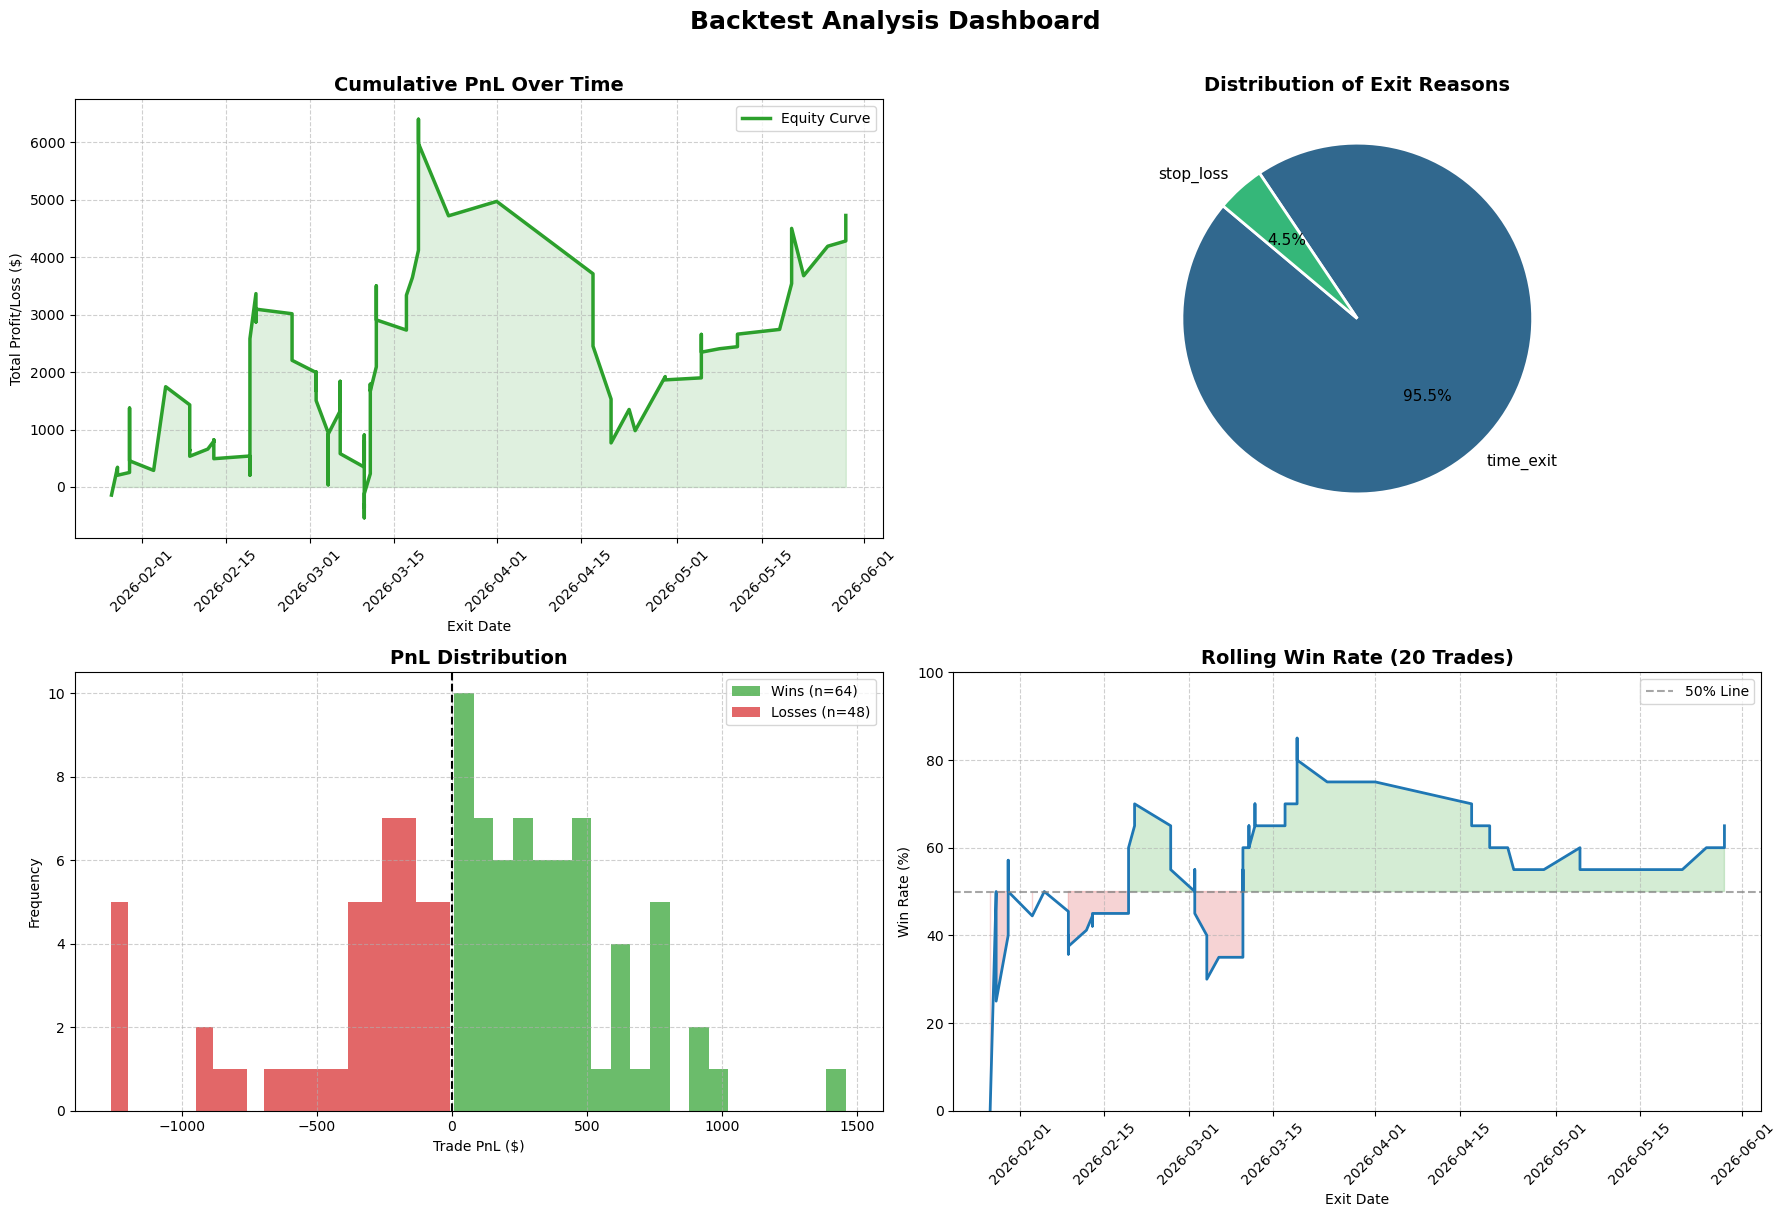

       BACKTEST SUMMARY
Total Trades:       112
Win Rate:           57.1%
Total PnL:          $4,727.78
Max Drawdown:       $-5,635.79
Profit Factor:      1.25
Median Win:         $309.77
Median Loss:        $-269.18
Avg Win:            $372.26
Avg Loss:           $-397.85
Avg R:              0.03R
Total R:            3.78R
----------------------------------------
Exit Reasons:
  time_exit             107 (95.5%)
  stop_loss               5 (4.5%)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. DATA PREPARATION ---
trades['exit_day'] = pd.to_datetime(trades['exit_day'])
trades = trades.sort_values(by='exit_day').reset_index(drop=True)
trades['cum_pnl_chronological'] = trades['trade_pnl'].cumsum()

# --- 2. VISUALIZATION ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
ax1, ax2, ax3, ax4 = axes.flatten()

# GRAPH A: Equity Curve
ax1.plot(trades['exit_day'], trades['cum_pnl_chronological'], color='#2ca02c', linewidth=2.5, label='Equity Curve')
ax1.fill_between(trades['exit_day'], trades['cum_pnl_chronological'], alpha=0.15, color='#2ca02c')
ax1.set_title('Cumulative PnL Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Exit Date')
ax1.set_ylabel('Total Profit/Loss ($)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

# GRAPH B: Exit Reason Distribution
exit_counts = trades['exit_reason'].value_counts()
colors = sns.color_palette('viridis', len(exit_counts))
ax2.pie(exit_counts,
        labels=exit_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 11})
ax2.set_title('Distribution of Exit Reasons', fontsize=14, fontweight='bold')

# GRAPH C: PnL Distribution (Histogram)
wins   = trades[trades['trade_pnl'] > 0]['trade_pnl']
losses = trades[trades['trade_pnl'] < 0]['trade_pnl']
ax3.hist(wins,   bins=20, color='#2ca02c', alpha=0.7, label=f'Wins (n={len(wins)})')
ax3.hist(losses, bins=20, color='#d62728', alpha=0.7, label=f'Losses (n={len(losses)})')
ax3.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax3.set_title('PnL Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Trade PnL ($)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6)

# GRAPH D: Rolling Win Rate (20-trade window)
trades['is_win'] = (trades['trade_pnl'] > 0).astype(int)
trades['rolling_winrate'] = trades['is_win'].rolling(window=20, min_periods=1).mean() * 100
ax4.plot(trades['exit_day'], trades['rolling_winrate'], color='#1f77b4', linewidth=2)
ax4.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Line')
ax4.fill_between(trades['exit_day'], trades['rolling_winrate'], 50,
                 where=trades['rolling_winrate'] >= 50, alpha=0.2, color='#2ca02c')
ax4.fill_between(trades['exit_day'], trades['rolling_winrate'], 50,
                 where=trades['rolling_winrate'] < 50,  alpha=0.2, color='#d62728')
ax4.set_title('Rolling Win Rate (20 Trades)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Exit Date')
ax4.set_ylabel('Win Rate (%)')
ax4.set_ylim(0, 100)
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.tick_params(axis='x', rotation=45)

plt.suptitle('Backtest Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- 3. CONSOLE SUMMARY ---
total_trades  = len(trades)
win_rate      = (trades['trade_pnl'] > 0).mean() * 100
total_pnl     = trades['trade_pnl'].sum()
median_win    = wins.median()   if len(wins)   > 0 else 0
median_loss   = losses.median() if len(losses) > 0 else 0
avg_win       = wins.mean()     if len(wins)   > 0 else 0
avg_loss      = losses.mean()   if len(losses) > 0 else 0
profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 else float('inf')
max_drawdown  = (trades['cum_pnl_chronological'] - trades['cum_pnl_chronological'].cummax()).min()
avg_r         = trades['pnl_r_initial_risk'].mean()
total_r       = trades['pnl_r_initial_risk'].sum()

print("=" * 40)
print("       BACKTEST SUMMARY")
print("=" * 40)
print(f"Total Trades:       {total_trades}")
print(f"Win Rate:           {win_rate:.1f}%")
print(f"Total PnL:          ${total_pnl:,.2f}")
print(f"Max Drawdown:       ${max_drawdown:,.2f}")
print(f"Profit Factor:      {profit_factor:.2f}")
print(f"Median Win:         ${median_win:,.2f}")
print(f"Median Loss:        ${median_loss:,.2f}")
print(f"Avg Win:            ${avg_win:,.2f}")
print(f"Avg Loss:           ${avg_loss:,.2f}")
print(f"Avg R:              {avg_r:.2f}R")
print(f"Total R:            {total_r:.2f}R")
print("-" * 40)
print("Exit Reasons:")
for reason, count in exit_counts.items():
    print(f"  {reason:<20} {count:>4} ({count/total_trades*100:.1f}%)")
print("=" * 40)

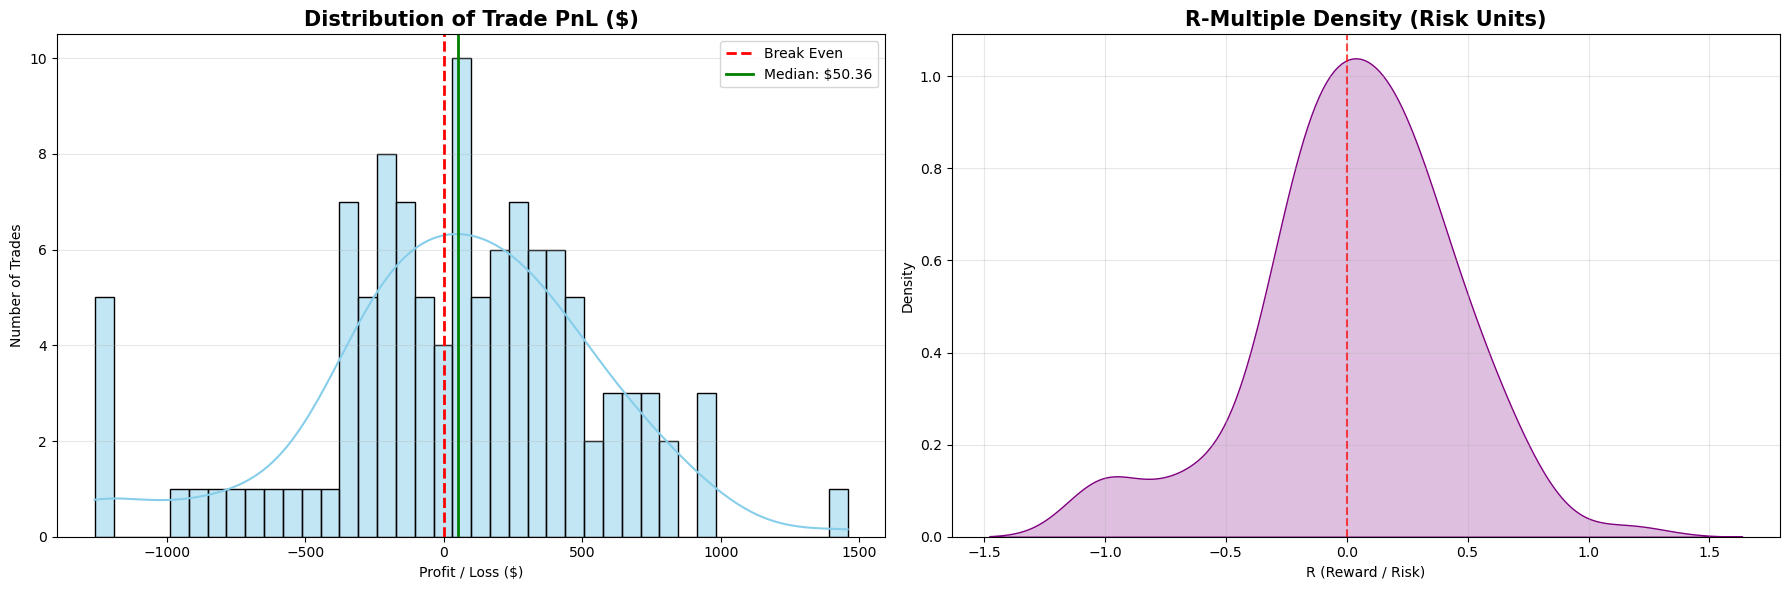

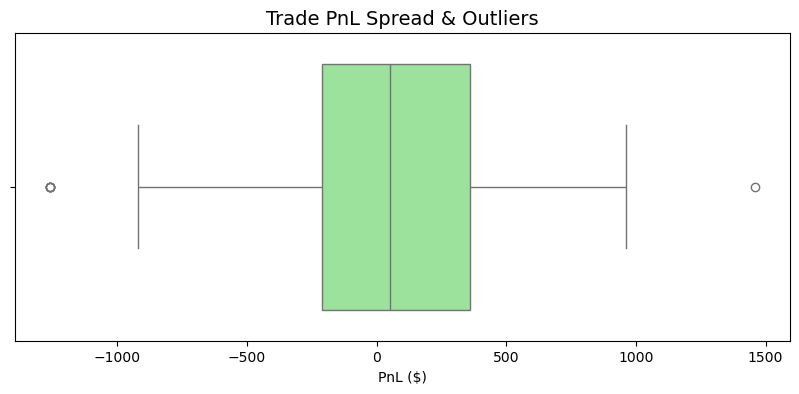

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. PnL Distribution (Absolute Dollars)
sns.histplot(trades['trade_pnl'], bins=40, kde=True, ax=ax1, color='skyblue', edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Break Even')
ax1.axvline(trades['trade_pnl'].median(), color='green', linestyle='-', linewidth=2, 
            label=f"Median: ${trades['trade_pnl'].median():.2f}")

ax1.set_title('Distribution of Trade PnL ($)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Profit / Loss ($)')
ax1.set_ylabel('Number of Trades')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. R-Multiple Distribution (Performance relative to initial risk)
# Note: Ensure 'pnl_r_initial_risk' exists in your 'trades' dataframe
sns.kdeplot(trades['pnl_r_initial_risk'], fill=True, color='purple', ax=ax2)
ax2.axvline(0, color='red', linestyle='--', alpha=0.7)

ax2.set_title('R-Multiple Density (Risk Units)', fontsize=15, fontweight='bold')
ax2.set_xlabel('R (Reward / Risk)')
ax2.set_ylabel('Density')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Boxplot for Outliers ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=trades['trade_pnl'], color='lightgreen')
plt.title('Trade PnL Spread & Outliers', fontsize=14)
plt.xlabel('PnL ($)')
plt.show()

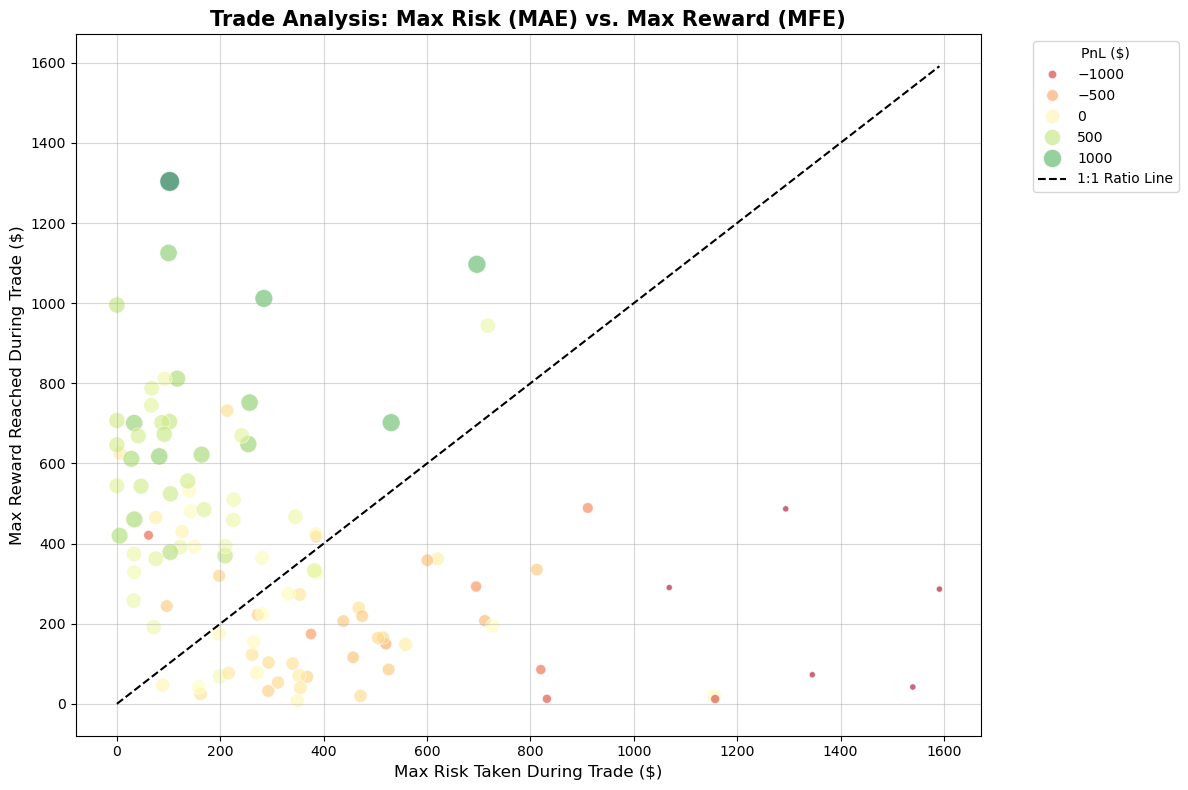

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a Scatter Plot of Max Risk vs Max Reward
plt.figure(figsize=(12, 8))

# We use 'trade_pnl' to color the dots (Green = Win, Red = Loss)
scatter = sns.scatterplot(
    data=trades, 
    x='max_risk', 
    y='max_reward', 
    hue='trade_pnl', 
    palette='RdYlGn', 
    size='trade_pnl',
    sizes=(20, 200),
    alpha=0.6
)

# Add a 1:1 Risk/Reward Line for reference
line_val = max(trades['max_risk'].max(), trades['max_reward'].max())
plt.plot([0, line_val], [0, line_val], color='black', linestyle='--', label='1:1 Ratio Line')

plt.title('Trade Analysis: Max Risk (MAE) vs. Max Reward (MFE)', fontsize=15, fontweight='bold')
plt.xlabel('Max Risk Taken During Trade ($)', fontsize=12)
plt.ylabel('Max Reward Reached During Trade ($)', fontsize=12)
plt.legend(title="PnL ($)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

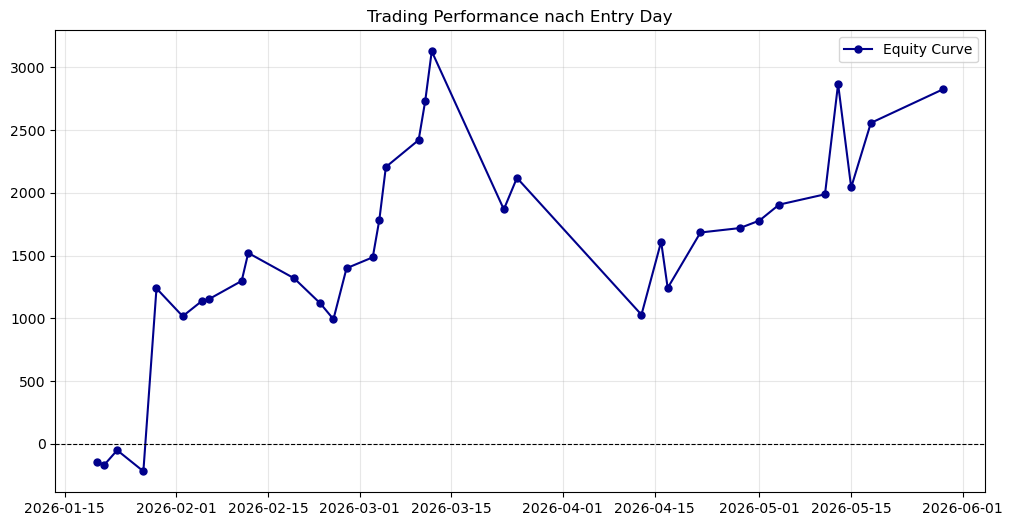

In [27]:
import matplotlib.pyplot as plt

daily_pnl = trades.groupby("entry_day")["trade_pnl"].median()

plt.figure(figsize=(12, 6))

plt.plot(daily_pnl.index, daily_pnl.cumsum(), color='darkblue', marker='o', markersize=5, label='Equity Curve')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Nulllinie zur Orientierung
plt.title('Trading Performance nach Entry Day')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

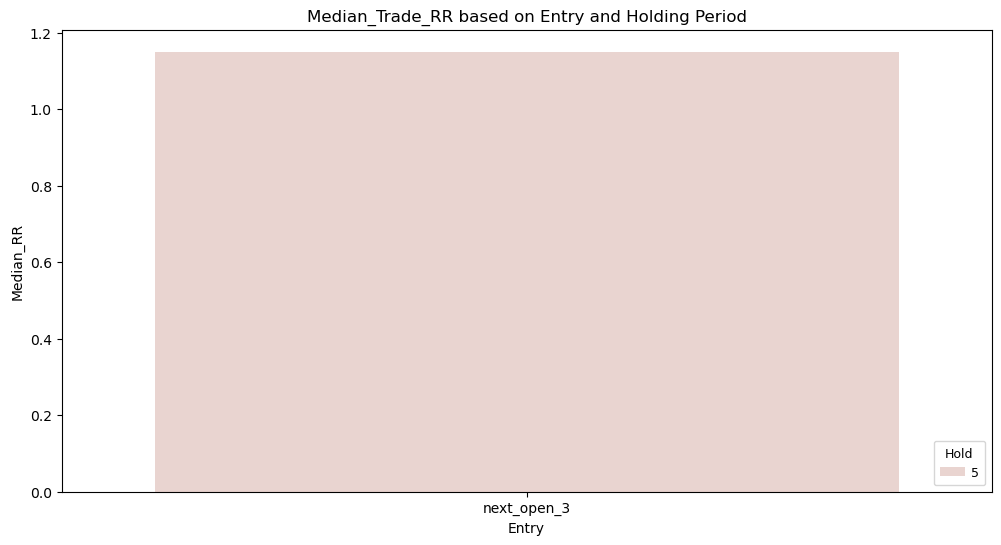

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))


ax = sns.barplot(
    data=df, 
    x='Entry', 
    y='Median_RR', 
    hue='Hold', 
    estimator='mean', 
    errorbar=None
)

plt.title('Median_Trade_RR based on Entry and Holding Period')

plt.legend(
    title='Hold', 
    loc='lower right', 
    fontsize=9,          # Text der Einträge
    title_fontsize=9,    # Text der Überschrift
    labelspacing=0.5,    # Vertikaler Abstand zwischen den Zeilen
    handletextpad=0.5,   # Abstand zwischen Farbfeld und Text
    borderpad=0.5        # Rand innerhalb der Legendenbox
)
plt.show()

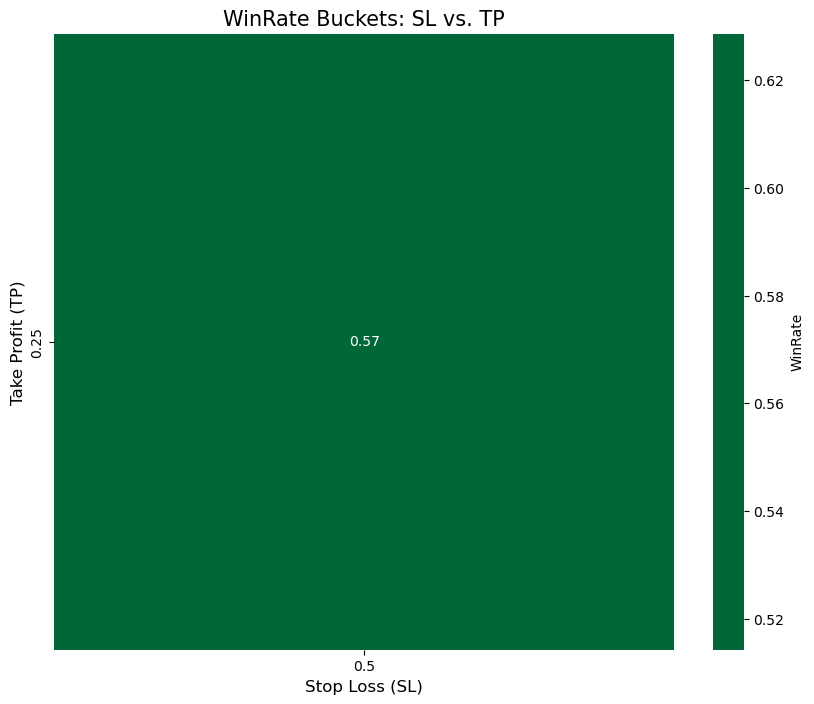

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pivot_table = df.pivot_table(
    index='SL', 
    columns='TP', 
    values='WinRate', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    pivot_table, 
    annot=True,         
    fmt=".2f",           
    cmap="RdYlGn",       
    center=0,            
    cbar_kws={'label': 'WinRate'}
)

plt.title('WinRate Buckets: SL vs. TP', fontsize=15)
plt.xlabel('Stop Loss (SL)', fontsize=12)
plt.ylabel('Take Profit (TP)', fontsize=12)

plt.show()

In [425]:
trades[trades.trade_pnl>0].trade_pnl.count()

trades[trades.trade_pnl<0].trade_pnl.count()

116